# IMKA evaluation summary — `qwen-imka` run

Plots a summary of one evaluation run from three files in the same folder as this notebook (`test/output/`):

| File | Produced by | What it holds |
|---|---|---|
| `answers-<run>.json` | `run-questions-qwen-imka.py` | question, rewritten query, answer, citations, context, latency |
| `ragas-<run>.json` | `evaluate-ragas.py` | RAGAS scores per question, per judge model |
| `retrieval-<run>.json` | `evaluate-retrieval.py` | page-level hit@k / MRR of the reranked context |

Change `RUN` below to summarize a different run with the same file layout.
Needs `pandas` and `matplotlib` (`pip install pandas matplotlib`).

In [71]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

RUN = "qwen-imka"
JUDGE = "luna"        # RAGAS judge to plot; see the judge coverage table below
ACCURACY_PASS = 1.0   # answer_accuracy at or above this counts as a correct answer
SAVE_FIGS = False     # True writes each figure to figures-<RUN>/ next to the data

# The notebook lives in test/output/; also works if the kernel starts in test/ or the repo root.
OUTPUT_DIR = next(p for p in (Path("."), Path("output"), Path("test/output"))
                  if (p / f"answers-{RUN}.json").is_file())
FIG_DIR = OUTPUT_DIR / f"figures-{RUN}"


def load(kind):
    with open(OUTPUT_DIR / f"{kind}-{RUN}.json", encoding="utf-8") as f:
        return json.load(f)


answers = load("answers")
ragas = load("ragas")
retrieval = load("retrieval")
print(f"Loaded from {OUTPUT_DIR.resolve()}")

Loaded from D:\git\fumeng1994\IMKA_Knowledge_Assistant_ChatBot\test\output


In [72]:
# Chart style: light surface, recessive grid/axes, fixed categorical order.
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
# Score scale for RAGAS: red = bad (0), neutral gray = middling (0.5), green = good (1).
RED_GREEN = LinearSegmentedColormap.from_list(
    "red_green", ["#a82b2b", "#d03b3b", "#ec9a8f", "#f0efec", "#8fcf8f", "#2e9e2e", "#0a6e0a"])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.family": ["Segoe UI", "DejaVu Sans", "sans-serif"], "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "legend.frameon": False, "legend.labelcolor": INK_2,
    "lines.linewidth": 2, "patch.linewidth": 0,
})


def finish(fig, name):
    fig.tight_layout()
    if SAVE_FIGS:
        FIG_DIR.mkdir(exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


def heatmap(ax, table, vmin=0.0, vmax=1.0, fmt="{:.2f}", cmap=BLUES):
    # Heatmap with value labels; NaN cells stay blank.
    data = table.to_numpy(dtype=float)
    ax.imshow(np.ma.masked_invalid(data), cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(table.shape[1]), table.columns, rotation=30, ha="right")
    ax.set_yticks(range(table.shape[0]), table.index)
    ax.grid(False)
    for side in ax.spines.values():
        side.set_visible(False)
    # 2px surface gap between cells
    ax.set_xticks(np.arange(-0.5, table.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, table.shape[0]), minor=True)
    ax.grid(which="minor", color=SURFACE, linewidth=2)
    ax.tick_params(which="minor", length=0)
    for (i, j), v in np.ndenumerate(data):
        if not np.isnan(v):
            t = (v - vmin) / (vmax - vmin)
            # BLUES darkens toward 1; RED_GREEN darkens toward both ends.
            dark_cell = abs(t - 0.5) > 0.3 if cmap is RED_GREEN else t > 0.55
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=9,
                    color="#ffffff" if dark_cell else INK)

## Run overview

In [73]:
ans = pd.DataFrame(answers["results"])
ans["answer_chars"] = ans["answer"].str.len()
ans["n_citations"] = ans["citations"].apply(len)
ans["cited_pages"] = ans["citations"].apply(lambda cs: sorted({c.get("page") for c in cs if c.get("page") is not None}))

overview = pd.Series({
    "model": answers["model"],
    "answers generated": answers["generated_at"],
    "questions answered": f'{answers["count"]} / {answers["total"]}',
    "generation errors": answers["errors"],
    "latency median (s)": round(ans["elapsed_s"].median(), 1),
    "latency p90 (s)": round(ans["elapsed_s"].quantile(0.9), 1),
    "latency max (s)": round(ans["elapsed_s"].max(), 1),
    "total generation time (min)": round(ans["elapsed_s"].sum() / 60, 1),
    "RAGAS scored": ragas["generated_at"],
    "retrieval scored": f'{retrieval["count"]} / {retrieval["questions_total"]} questions',
    "retrieval skipped": ", ".join(f'Q{s["id"]}' for s in retrieval["skipped"]) or "none",
}, name="value")
overview.to_frame()

,value
model,qwen3.8-27b-q4
answers generated,2026-09-16T23:55:48
questions answered,70 / 70
generation errors,0
latency median (s),16.7
latency p90 (s),22.1
latency max (s),114.8
total generation time (min),21.5
RAGAS scored,2026-09-17T15:31:22
retrieval scored,67 / 70 questions


In [74]:
# Which judge covered how many questions — plots below use JUDGE only.
pd.DataFrame({
    name: {"judge model": j["model"], "provider": j["provider"], "metric API": j["metric_api"],
           "questions scored": j["count"], "errors": j["errors"]}
    for name, j in ragas["judges"].items()
}).T

,judge model,provider,metric API,questions scored,errors
luna,gpt-5.6-luna,openai,collections,70,0
qwen,qwen3.8-27b-q4,runpod,legacy,1,0


## 1. Answers (`answers-*.json`)

Latency per question and how the question set is spread across the RAG component each question targets.

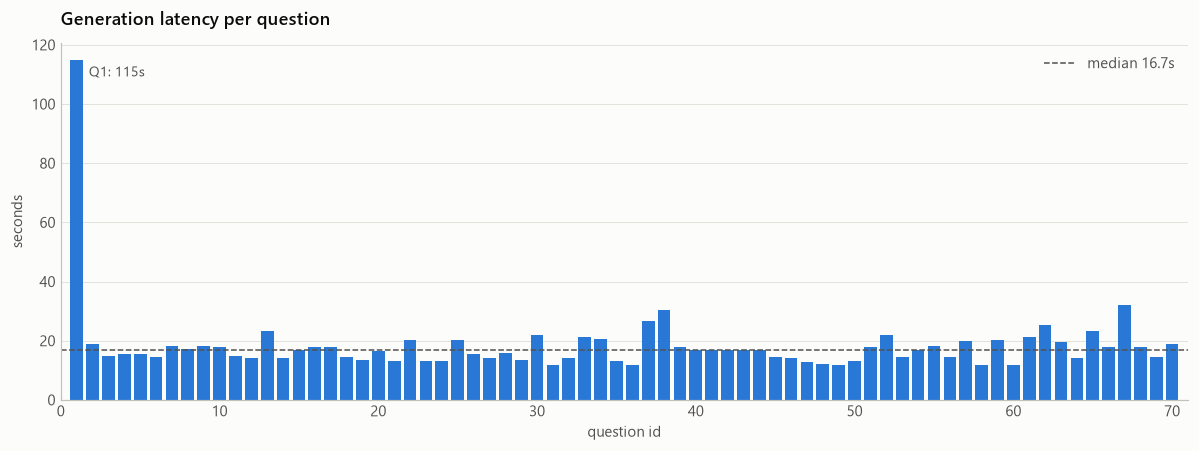

In [75]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(ans["id"], ans["elapsed_s"], width=0.8, color=SERIES[0])
med = ans["elapsed_s"].median()
ax.axhline(med, color=INK_2, linewidth=1, linestyle="--", label=f"median {med:.1f}s")
ax.legend(loc="upper right")
slowest = ans.loc[ans["elapsed_s"].idxmax()]
ax.annotate(f'Q{slowest["id"]}: {slowest["elapsed_s"]:.0f}s', (slowest["id"], slowest["elapsed_s"]),
            xytext=(8, -4), textcoords="offset points", va="top", color=INK_2, fontsize=9)
ax.set(title="Generation latency per question", xlabel="question id", ylabel="seconds", xlim=(0, ans["id"].max() + 1))
ax.grid(axis="x", visible=False)
finish(fig, "answers-latency")

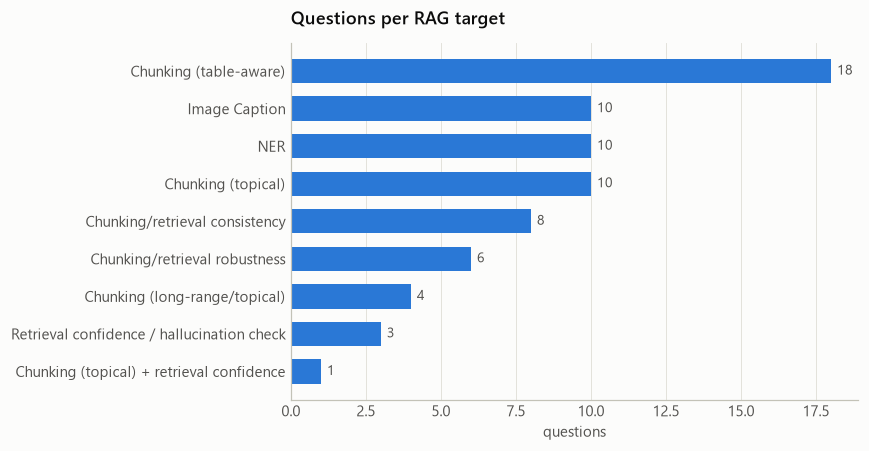

In [76]:
fig, ax = plt.subplots(figsize=(8, 4.2))
counts = ans["rag_target"].value_counts().sort_values()
ax.barh(counts.index, counts.values, height=0.65, color=SERIES[0])
for y, v in enumerate(counts.values):
    ax.text(v + 0.2, y, str(v), va="center", color=INK_2, fontsize=9)
ax.set(title="Questions per RAG target", xlabel="questions")
ax.grid(axis="y", visible=False)
finish(fig, "answers-targets")

C:\Users\fumen\AppData\Local\Temp\ipykernel_18896\204139746.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(groups, vert=False, tick_labels=[f"{t}  (n={len(g)})" for t, g in zip(order, groups)], widths=0.5,


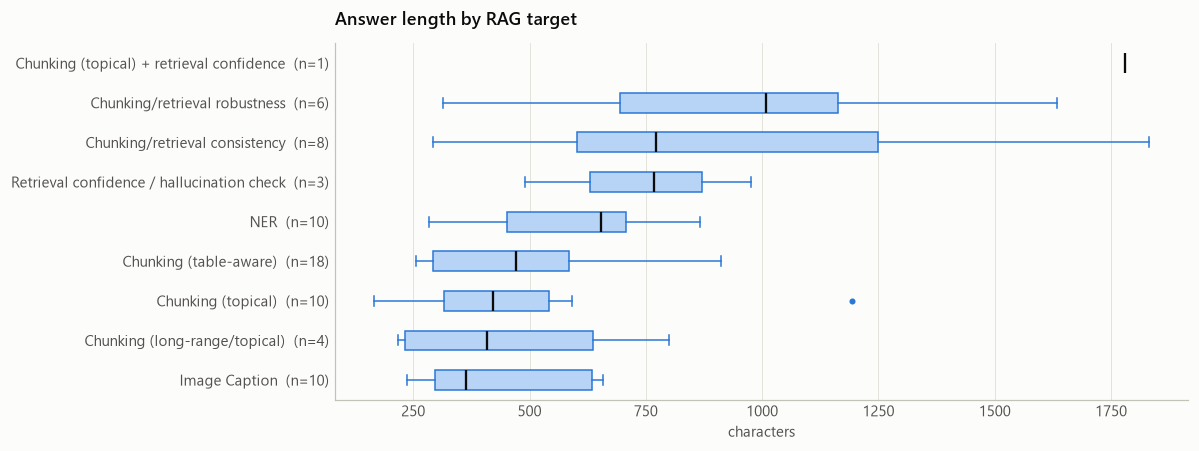

Citations per answer: {1: 70} (deduplicated by document_id)


In [77]:
fig, ax = plt.subplots(figsize=(11, 4.2))
order = ans.groupby("rag_target")["answer_chars"].median().sort_values().index
groups = [ans.loc[ans["rag_target"] == t, "answer_chars"] for t in order]
ax.boxplot(groups, vert=False, tick_labels=[f"{t}  (n={len(g)})" for t, g in zip(order, groups)], widths=0.5,
           patch_artist=True, medianprops={"color": INK, "linewidth": 1.5},
           boxprops={"facecolor": "#b7d3f6", "edgecolor": SERIES[0]},
           whiskerprops={"color": SERIES[0]}, capprops={"color": SERIES[0]},
           flierprops={"marker": "o", "markersize": 5, "markerfacecolor": SERIES[0], "markeredgecolor": SURFACE})
ax.set(title="Answer length by RAG target", xlabel="characters")
ax.grid(axis="y", visible=False)
finish(fig, "answers-length")
print("Citations per answer:", ans["n_citations"].value_counts().sort_index().to_dict(),
      "(deduplicated by document_id)")

## 2. RAGAS scores (`ragas-*.json`)

All metrics are 0–1, higher is better. *Absence probes* are fabricated questions whose correct answer is
"not in the manual", so they are shown separately — they inflate some metrics and deflate others.

In [78]:
METRICS = ragas["metrics"]
scores = pd.DataFrame([
    {"id": r["id"], "failure_type": r["failure_type"], "rag_target": r["rag_target"],
     "absence": r["reference_is_absence"], **r["scores"][JUDGE]}
    for r in ragas["results"] if r["scores"].get(JUDGE)
])

agg = ragas["aggregate"][JUDGE]
slices = {"all questions": "overall", "excluding absence probes": "excluding_absence_probes",
          "absence probes only": "absence_probes_only"}
summary = pd.DataFrame({label: {m: agg[key][m]["mean"] for m in METRICS} for label, key in slices.items()})
summary.loc["questions"] = [agg[key]["questions"] for key in slices.values()]
summary

,all questions,excluding absence probes,absence probes only
faithfulness,0.9853,0.9864,0.9729
answer_relevancy,0.6604,0.6746,0.5089
context_precision,0.6515,0.6365,0.8118
context_recall,0.7714,0.7500,1.0000
answer_accuracy,0.7429,0.7344,0.8333
semantic_similarity,0.4039,0.4007,0.4375
questions,70.0000,64.0000,6.0000


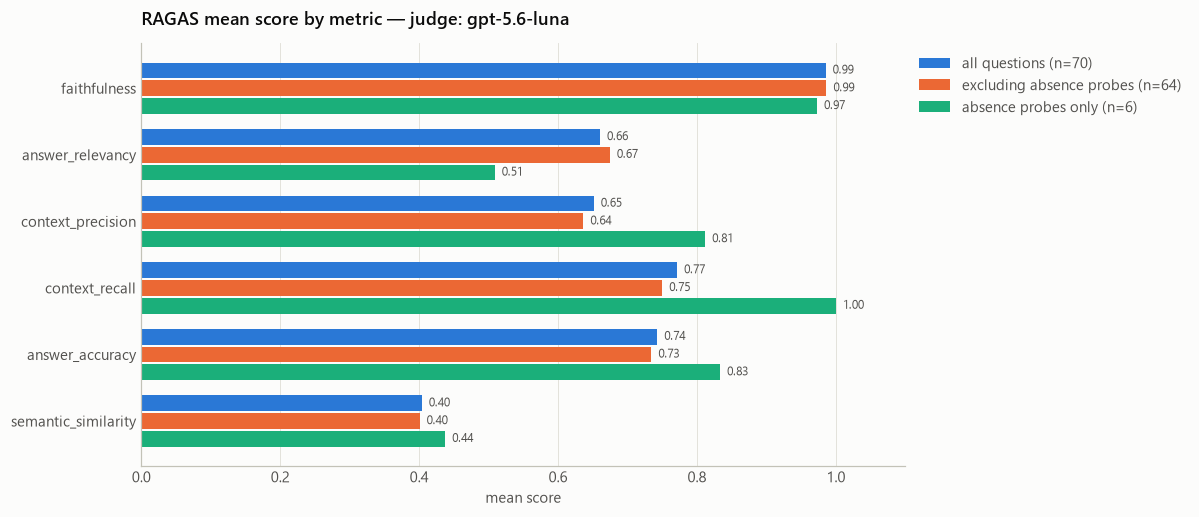

In [79]:
fig, ax = plt.subplots(figsize=(11, 4.8))
labels = list(slices)
n = len(labels)
h = 0.8 / n
y = np.arange(len(METRICS))[::-1]
for i, label in enumerate(labels):
    vals = summary.loc[METRICS, label].astype(float).to_numpy()
    pos = y + (n - 1) / 2 * h - i * h
    ax.barh(pos, vals, height=h - 0.03, color=SERIES[i], label=f"{label} (n={int(summary.loc['questions', label])})")
    for p, v in zip(pos, vals):
        if not np.isnan(v):
            ax.text(v + 0.01, p, f"{v:.2f}", va="center", fontsize=8, color=INK_2)
ax.set_yticks(y, METRICS)
ax.set(xlim=(0, 1.1), xlabel="mean score", title=f"RAGAS mean score by metric — judge: {ragas['judges'][JUDGE]['model']}")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
finish(fig, "ragas-means")

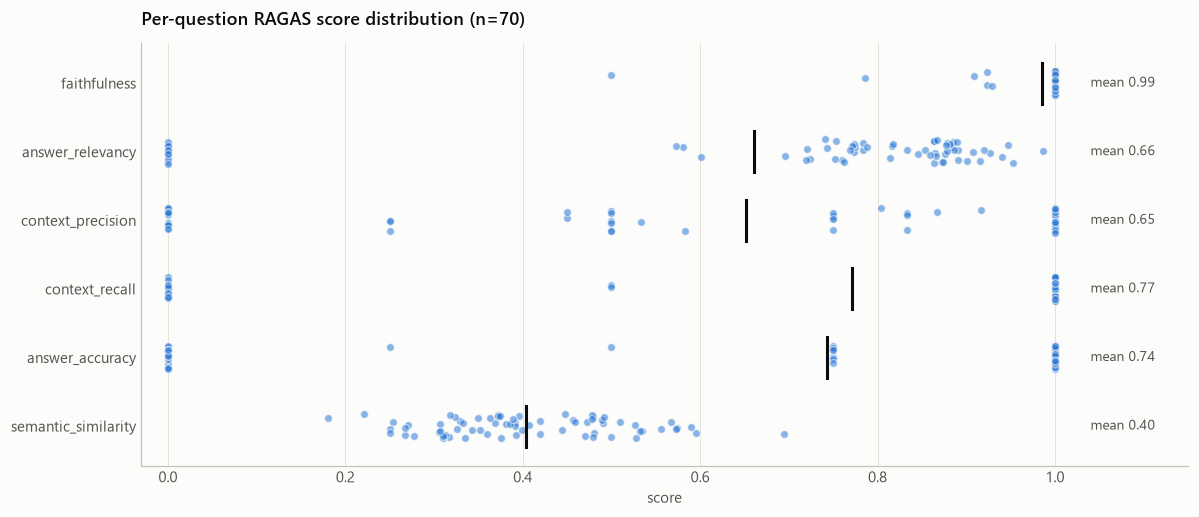

In [80]:
# Every question's score as a dot (jittered), with the mean as a dark bar.
fig, ax = plt.subplots(figsize=(11, 4.8))
rng = np.random.default_rng(0)
for i, m in enumerate(METRICS[::-1]):
    vals = scores[m].dropna()
    jitter = rng.uniform(-0.18, 0.18, len(vals))
    ax.scatter(vals, i + jitter, s=26, color=SERIES[0], alpha=0.55, edgecolor=SURFACE, linewidth=0.8)
    ax.plot([vals.mean()] * 2, [i - 0.3, i + 0.3], color=INK, linewidth=2)
    ax.text(1.04, i, f"mean {vals.mean():.2f}", va="center", fontsize=9, color=INK_2)
ax.set_yticks(range(len(METRICS)), METRICS[::-1])
ax.set(xlim=(-0.03, 1.15), xlabel="score", title=f"Per-question RAGAS score distribution (n={len(scores)})")
ax.grid(axis="y", visible=False)
finish(fig, "ragas-distribution")

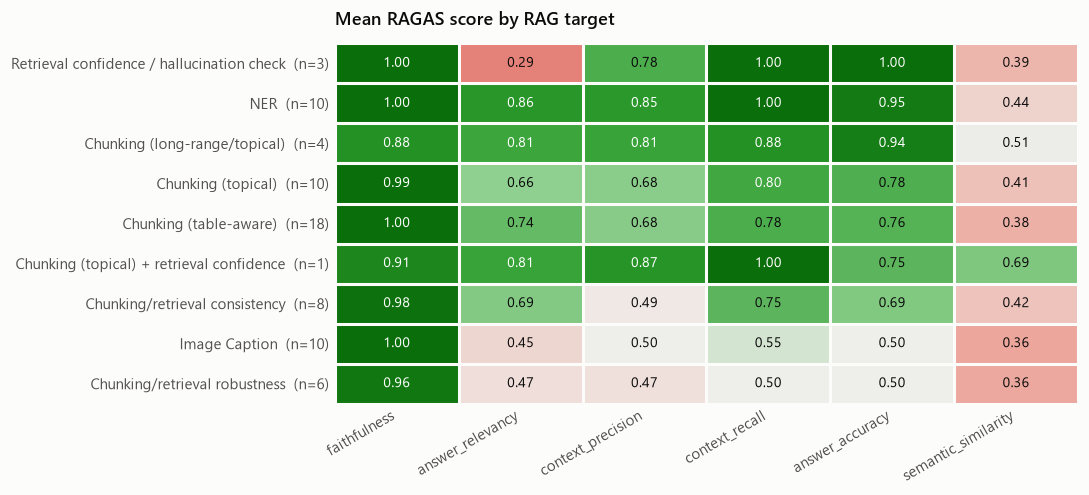

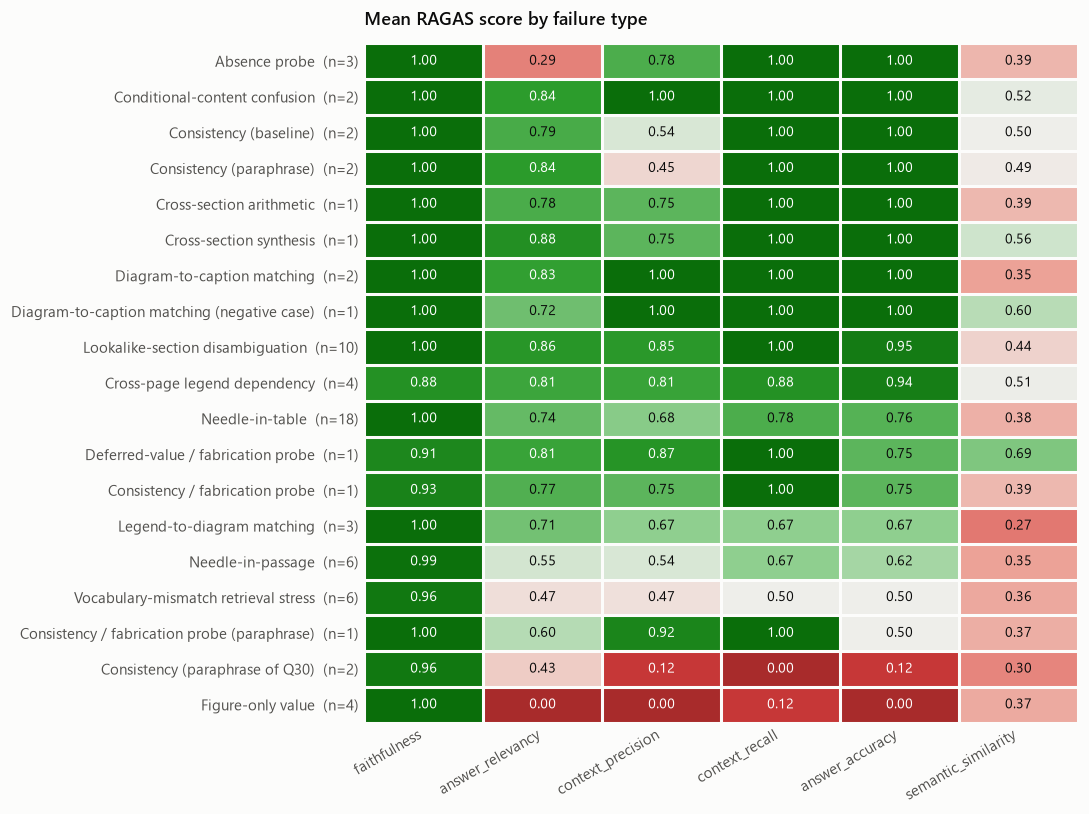

In [81]:
def by_group(df, col):
    t = df.groupby(col)[METRICS].mean()
    n = df[col].value_counts()
    t = t.sort_values("answer_accuracy", ascending=False)
    t.index = [f"{g}  (n={n[g]})" for g in t.index]
    return t

fig, ax = plt.subplots(figsize=(10, 4.6))
heatmap(ax, by_group(scores, "rag_target"), cmap=RED_GREEN)
ax.set_title("Mean RAGAS score by RAG target")
finish(fig, "ragas-by-target")

fig, ax = plt.subplots(figsize=(10, 7.5))
heatmap(ax, by_group(scores, "failure_type"), cmap=RED_GREEN)
ax.set_title("Mean RAGAS score by failure type")
finish(fig, "ragas-by-failure-type")

## 3. Retrieval (`retrieval-*.json`)

A retrieved chunk counts as relevant when its page matches a page named in the question's `source`.
`exact` requires the same page; `within_1_page` tolerates an off-by-one page (chunks that straddle a page break).
Ranked list = the final reranked context (top 5) the answer was generated from.

In [82]:
TOLS = ["exact", "within_1_page"]
KS = retrieval["method"]["k"]
ret = pd.DataFrame([
    {"id": r["id"], "failure_type": r["failure_type"], "rag_target": r["rag_target"],
     **{f"{tol}:{k}": v for tol in TOLS for k, v in r["metrics"][tol].items()}}
    for r in retrieval["results"]
])
overall = retrieval["aggregate"]["overall"]
pd.DataFrame({tol: overall[tol] for tol in TOLS})

,exact,within_1_page
hit_rate@1,0.6269,0.7313
hit_rate@3,0.6866,0.9254
hit_rate@5,0.7015,0.9552
mrr,0.6604,0.8301


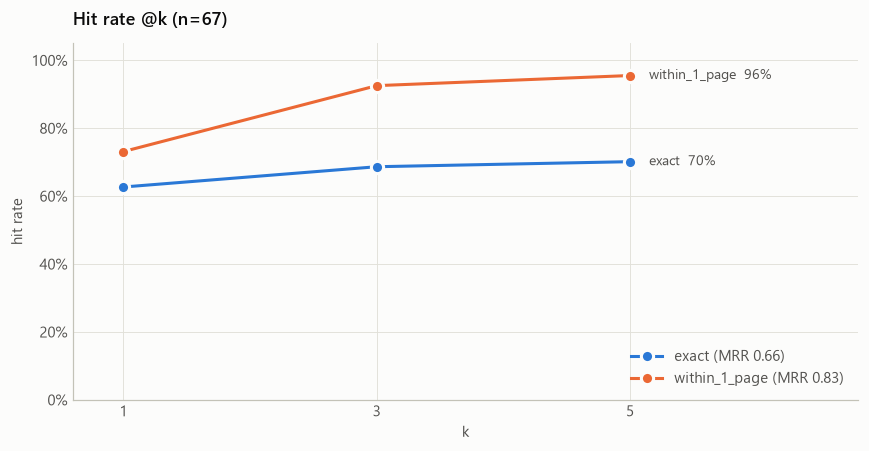

In [83]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for i, tol in enumerate(TOLS):
    vals = [overall[tol][f"hit_rate@{k}"] for k in KS]
    ax.plot(KS, vals, color=SERIES[i], marker="o", markersize=8, markeredgecolor=SURFACE, markeredgewidth=2,
            label=f"{tol} (MRR {overall[tol]['mrr']:.2f})")
    ax.text(KS[-1] + 0.15, vals[-1], f"{tol}  {vals[-1]:.0%}", va="center", color=INK_2, fontsize=9)
ax.set(xticks=KS, xlim=(0.6, KS[-1] + 1.8), ylim=(0, 1.05), xlabel="k", ylabel="hit rate",
       title=f"Hit rate @k (n={overall['questions']})")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(loc="lower right")
finish(fig, "retrieval-hit-rate")

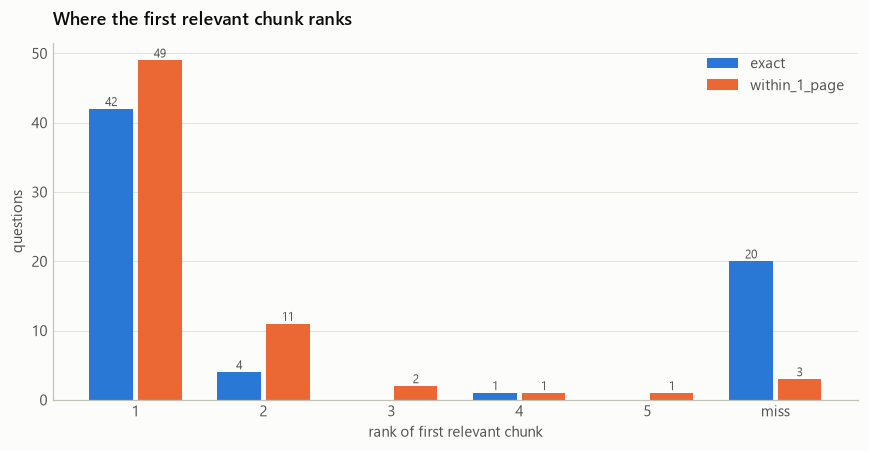

In [84]:
# Rank at which the first relevant chunk appeared; "miss" = not in the top 5.
fig, ax = plt.subplots(figsize=(8, 4.2))
max_k = retrieval["method"]["max_retrieved"]
ranks = [str(k) for k in range(1, max_k + 1)] + ["miss"]
x = np.arange(len(ranks))
w = 0.38
for i, tol in enumerate(TOLS):
    first = ret[f"{tol}:first_relevant_rank"].apply(lambda r: "miss" if pd.isna(r) else str(int(r)))
    cnt = first.value_counts().reindex(ranks, fill_value=0)
    pos = x + (i - 0.5) * w
    ax.bar(pos, cnt.values, width=w - 0.04, color=SERIES[i], label=tol)
    for p, v in zip(pos, cnt.values):
        if v:
            ax.text(p, v + 0.4, str(v), ha="center", fontsize=8, color=INK_2)
ax.set_xticks(x, ranks)
ax.set(xlabel="rank of first relevant chunk", ylabel="questions", title="Where the first relevant chunk ranks")
ax.grid(axis="x", visible=False)
ax.legend()
finish(fig, "retrieval-first-rank")

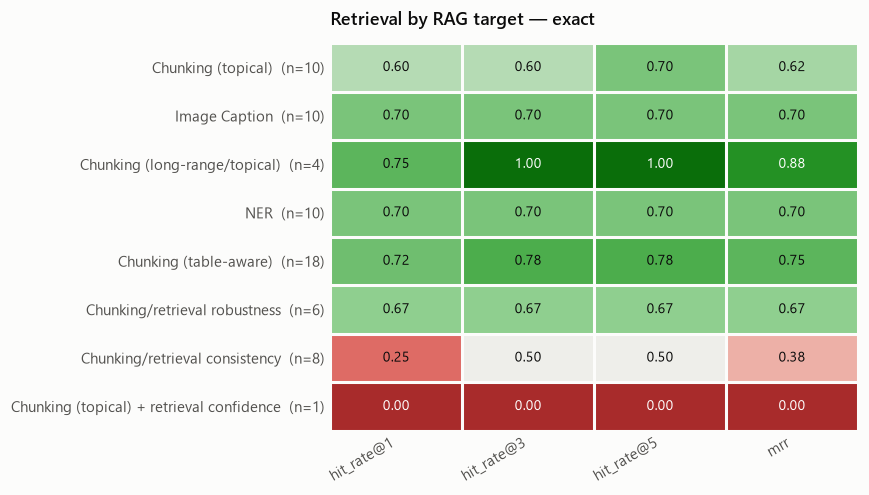

In [85]:
def retrieval_table(group, tol):
    rows = retrieval["aggregate"][group]
    t = pd.DataFrame({g: {**v[tol], "n": v["questions"]} for g, v in rows.items()}).T
    t = t.sort_values(["mrr", "n"], ascending=False)
    t.index = [f"{g}  (n={int(n)})" for g, n in zip(t.index, t["n"])]
    return t.drop(columns="n").astype(float)


def retrieval_heatmap(group, tol, title, height, cmap=BLUES):
    # Rows keep the within_1_page order so the exact and ±1 heatmaps line up.
    order = retrieval_table(group, "within_1_page").index
    fig, ax = plt.subplots(figsize=(8, height))
    heatmap(ax, retrieval_table(group, tol).loc[order], cmap=cmap)
    ax.set_title(f"{title} — {tol}")
    finish(fig, f"retrieval-{group.replace('_', '-')}-{tol.replace('_', '-')}")


retrieval_heatmap("by_rag_target", "exact", "Retrieval by RAG target", 4.6, cmap=RED_GREEN)

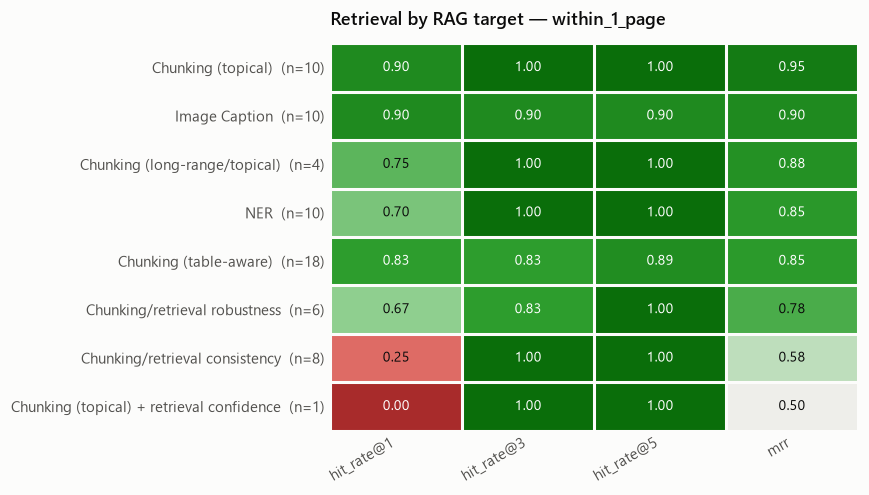

In [86]:
retrieval_heatmap("by_rag_target", "within_1_page", "Retrieval by RAG target", 4.6, cmap=RED_GREEN)

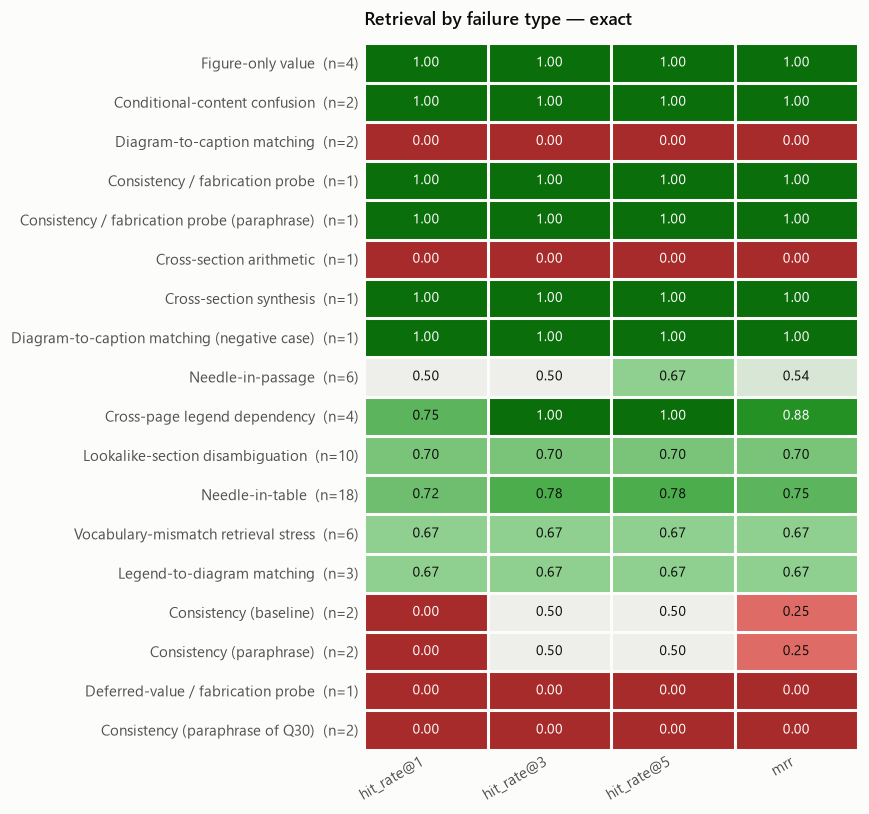

In [87]:
retrieval_heatmap("by_failure_type", "exact", "Retrieval by failure type", 7.5, cmap=RED_GREEN)

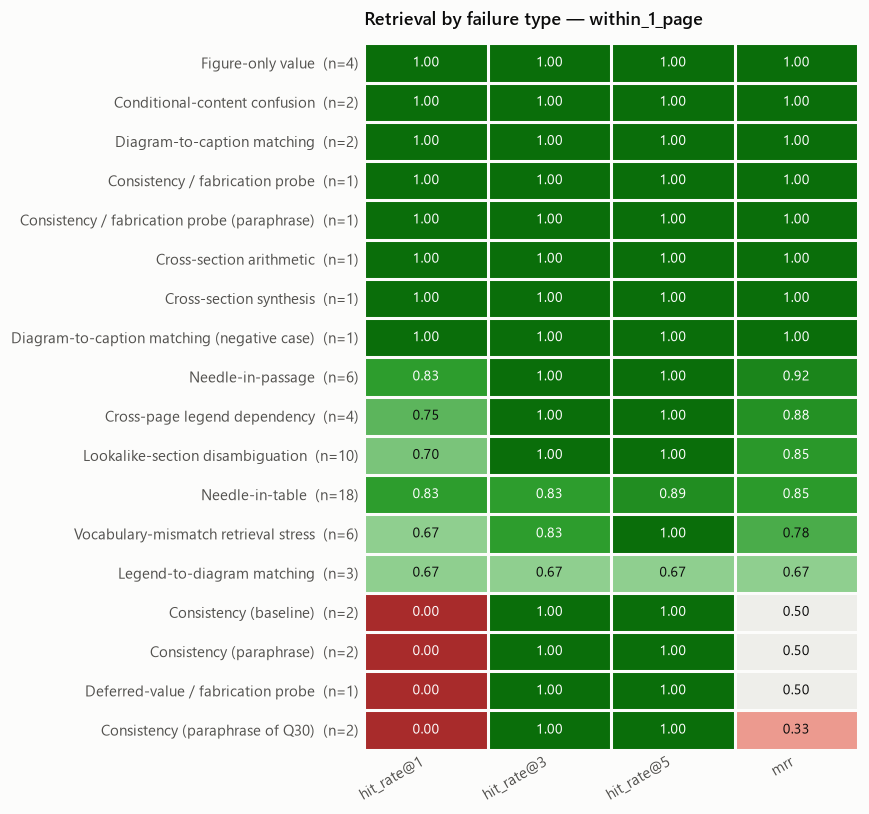

In [88]:
retrieval_heatmap("by_failure_type", "within_1_page", "Retrieval by failure type", 7.5, cmap=RED_GREEN)

## 4. Retrieval vs. generation — where does each question fail?

Joins the three files per question. A question is **retrieved** when the right page (±1) is in the top 5 context,
and **correct** when RAGAS `answer_accuracy` ≥ `ACCURACY_PASS`.

| Outcome | Meaning |
|---|---|
| retrieved · correct | pipeline worked |
| retrieved · not correct | right context was there — generation (or chunk content) failed; includes partial credit |
| missed · correct | answered without the named page (neighbouring chunk, duplicate content, or model knowledge) |
| missed · not correct | retrieval failure |
| no page to retrieve | fabricated / absence questions, not scored for retrieval |

In [89]:
joined = (
    ans[["id", "question", "rag_target", "failure_type", "expected_answer", "answer", "cited_pages", "elapsed_s"]]
    .merge(scores[["id"] + METRICS], on="id", how="left")
    .merge(ret[["id", "within_1_page:hit@5", "within_1_page:first_relevant_rank"]], on="id", how="left")
)
retrieved = joined["within_1_page:hit@5"]
correct = joined["answer_accuracy"] >= ACCURACY_PASS
joined["outcome"] = np.select(
    [retrieved.isna(), (retrieved == True) & correct, (retrieved == True) & ~correct, (retrieved == False) & correct],
    ["no page to retrieve", "retrieved · correct", "retrieved · not correct", "missed · correct"],
    default="missed · not correct",
)
OUTCOMES = ["retrieved · correct", "retrieved · not correct", "missed · correct", "missed · not correct", "no page to retrieve"]
OUTCOME_COLORS = SERIES[:4] + [AXIS]
joined["outcome"].value_counts().reindex(OUTCOMES, fill_value=0).to_frame("questions")

,questions
outcome,
retrieved · correct,41
retrieved · not correct,23
missed · correct,2
missed · not correct,1
no page to retrieve,3


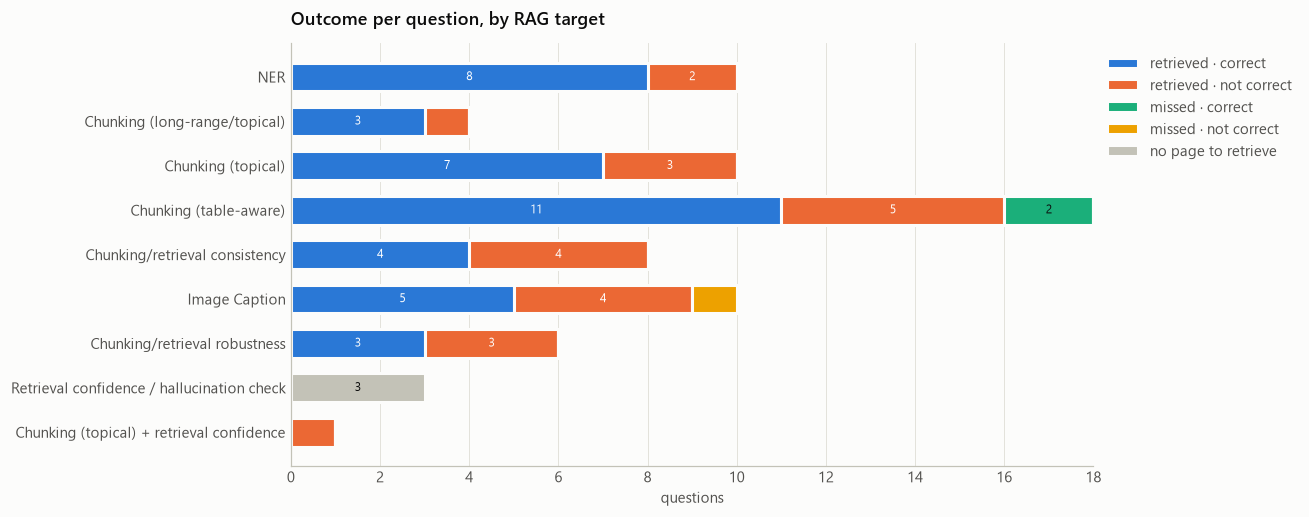

In [90]:
tab = pd.crosstab(joined["rag_target"], joined["outcome"]).reindex(columns=OUTCOMES, fill_value=0)
tab = tab.loc[(tab["retrieved · correct"] / tab.sum(axis=1)).sort_values().index]

fig, ax = plt.subplots(figsize=(12, 4.8))
left = np.zeros(len(tab))
for outcome, color in zip(OUTCOMES, OUTCOME_COLORS):
    vals = tab[outcome].to_numpy()
    # white edge = 2px surface gap between stacked segments
    ax.barh(tab.index, vals, left=left, height=0.65, color=color, edgecolor=SURFACE, linewidth=2, label=outcome)
    for y, (l, v) in enumerate(zip(left, vals)):
        if v >= 2:
            ax.text(l + v / 2, y, str(v), ha="center", va="center", fontsize=8,
                    color=INK if color in (SERIES[2], SERIES[3], AXIS) else "#ffffff")
    left += vals
ax.set(xlabel="questions", title="Outcome per question, by RAG target")
ax.grid(axis="y", visible=False)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
finish(fig, "outcome-by-target")

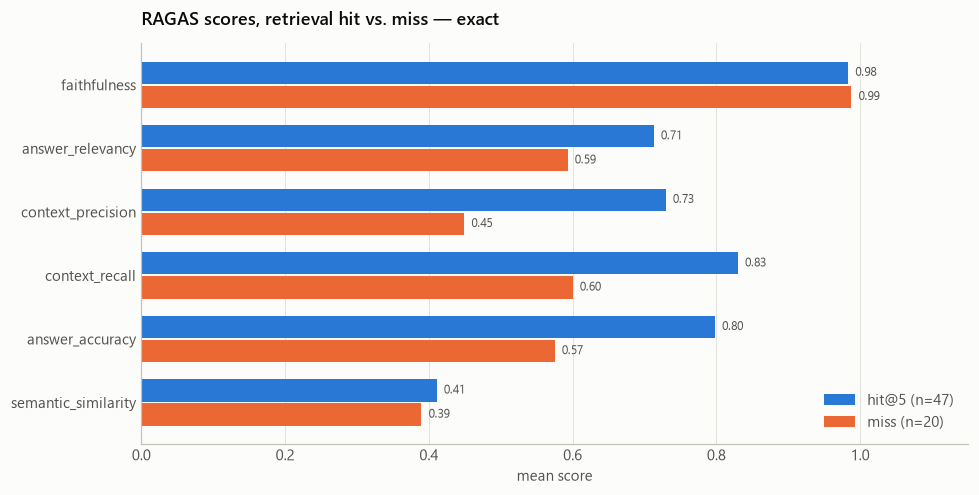

In [91]:
# Does retrieving the right page actually translate into better answers?
hits = ret[["id"] + [f"{tol}:hit@5" for tol in TOLS]].merge(scores[["id"] + METRICS], on="id")


def hit_vs_miss(tol):
    fig, ax = plt.subplots(figsize=(9, 4.6))
    y = np.arange(len(METRICS))[::-1]
    h = 0.38
    groups = {"hit@5": hits[hits[f"{tol}:hit@5"] == True], "miss": hits[hits[f"{tol}:hit@5"] == False]}
    for i, (label, df) in enumerate(groups.items()):
        vals = df[METRICS].mean().to_numpy()
        pos = y + (0.5 - i) * h
        ax.barh(pos, vals, height=h - 0.03, color=SERIES[i], label=f"{label} (n={len(df)})")
        for p, v in zip(pos, vals):
            if not np.isnan(v):
                ax.text(v + 0.01, p, f"{v:.2f}", va="center", fontsize=8, color=INK_2)
    ax.set_yticks(y, METRICS)
    ax.set(xlim=(0, 1.15), xlabel="mean score", title=f"RAGAS scores, retrieval hit vs. miss — {tol}")
    ax.grid(axis="y", visible=False)
    ax.legend(loc="lower right")
    finish(fig, f"ragas-by-retrieval-hit-{tol.replace('_', '-')}")


hit_vs_miss("exact")

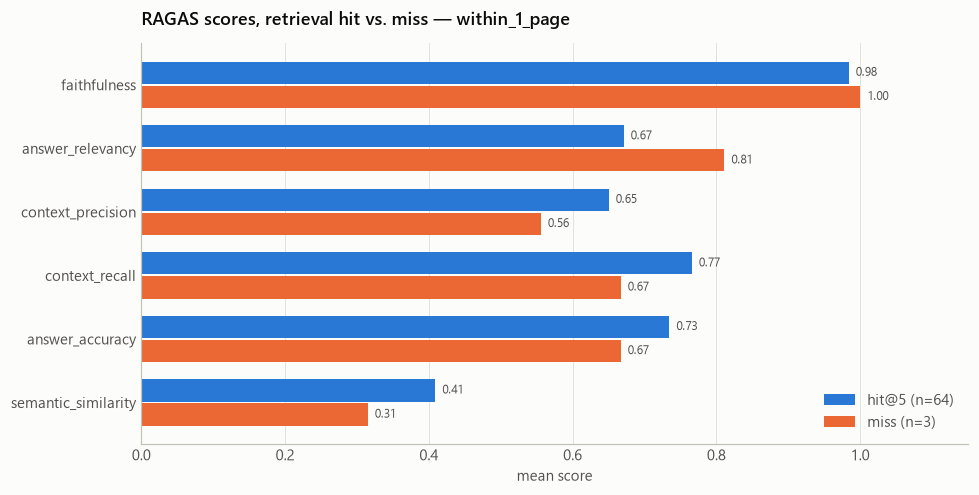

In [92]:
hit_vs_miss("within_1_page")

### Questions that did not get a correct answer

Sorted so generation failures (right context retrieved, wrong answer) come first.

In [93]:
pd.set_option("display.max_colwidth", 160)
failures = joined[~correct & (joined["outcome"] != "no page to retrieve")].copy()
failures["answer"] = failures["answer"].str.replace(r"\s+", " ", regex=True).str.slice(0, 160)
failures.sort_values(["outcome", "answer_accuracy", "id"])[
    ["id", "outcome", "rag_target", "question", "expected_answer", "answer",
     "answer_accuracy", "faithfulness", "context_recall", "within_1_page:first_relevant_rank"]
].set_index("id").style.format(precision=2, na_rep="–")

,outcome,rag_target,question,expected_answer,answer,answer_accuracy,faithfulness,context_recall,within_1_page:first_relevant_rank
id,,,,,,,,,
50,missed · not correct,Image Caption,"In the direction-of-rotation diagram, which item number represents 'Reversing'?",item 9,"Based on the provided context, there is no information regarding a ""Direction-of-rotation diagram"" or a specific ""item number"" for 'Reversing'. The context ment",0.00,1.00,0.00,–
1,retrieved · not correct,Chunking (table-aware),"What is the Pt-100 resistance, in ohms, at exactly 100°C according to Table 11?",138.50 Ω,"Based on the provided context, the specific resistance value for a Pt-100 detector at 100°C is **not available**. The context includes an excerpt from **Table 1",0.00,1.00,0.00,1.00
2,retrieved · not correct,Chunking (table-aware),"What is the Pt-100 resistance, in ohms, at exactly 40°C according to Table 11?",115.54 Ω,"Based on the provided context, the specific resistance value for a Pt-100 detector at 40°C is **not explicitly listed** in the excerpt of Table 11 provided on p",0.00,1.00,0.00,1.00
4,retrieved · not correct,Chunking (table-aware),What is the tightening torque (Nm) for a dry M20 bolt of property class 8.8?,390 Nm,"Based on the provided context, the specific tightening torque for an **M20** bolt is **not included** in the available text. The context provides a table of gen",0.00,1.00,0.00,1.00
30,retrieved · not correct,Chunking (topical),How long should the first test start of the machine last?,about one (1) second,"Based on the provided context, there is **no information** regarding a recommended duration or time limit for the initial machine test start. The context provid",0.00,0.92,0.00,2.00
32,retrieved · not correct,Chunking (topical),"As a thumb rule, how often should an insulation resistance test be performed?",once a year,"Based on the provided context, there is **no information** regarding the recommended frequency (e.g., how often per year or operating hours) for insulation resi",0.00,1.00,0.00,1.00
33,retrieved · not correct,Chunking/retrieval consistency,How long should the initial start of the machine last?,about one (1) second,"Based on the provided context, there is **no information** regarding a specific recommended duration (e.g., in minutes or hours) for the initial machine startup",0.00,0.92,0.00,3.00
41,retrieved · not correct,Image Caption,"From Figure 42, at 18 brushes with a carbon brush wear rate of 3 mm/10³h, what's the approximate maximum cleaning interval?",≈10–12 ×10³ h (approximate graph reading),"Based on the provided context, I cannot determine the specific maximum cleaning interval for a carbon brush wear rate of 3 mm/10³h with 18 brushes. The context",0.00,1.00,0.00,1.00
42,retrieved · not correct,Image Caption,"From Figure 42, at 6 brushes with the lowest wear rate (1 mm/10³h), what's the approximate maximum cleaning interval?","≈40 ×10³ h (approximate graph reading, near chart's upper limit)","Based on the provided context, it is **not possible** to determine the maximum cleaning interval for 6 brushes with a wear rate of 1 mm/10³h. The context on pag",0.00,1.00,0.00,1.00
